# Использование библиотеки pandas

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

## Задание 1

Загрузите данные из файла «athlete_events.csv» о спортсменах – участниках
олимпийских игр (ОИ).

Данные содержат следующие признаки:
* ID – уникальный идентификатор спортсмена
* Name – имя спортсмена
* Sex – пол (M – мужской, F – женский)
* Age – возраст (полных лет, целое число)
* Height – рост в сантиметрах
* Weight – вес в килограммах
* Team – название команды (страны)
* NOC – трехбуквенное обозначение страны (по стандарту МОК)
* Games – год и вид ОИ (летние или зимние)
* Year – год проведения ОИ
* Season – вид ОИ (летние или зимние)
* City – город проведения ОИ
* Sport – вид спорта
* Event – соревнование (дисциплина)
* Medal – завоеванная медаль (Gold, Silver, Bronze или NA)

In [ ]:
data = pd.read_csv("data/athlete_events.csv")
data.head(5)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


1. Определите количество значений каждого из признаков в загруженных данных. По каким значениям имеются не все данные? По какому значению отсутствующих данных больше всего? Подсказка: воспользуйтесь функцией count или info. 

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [14]:
data.isnull().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

In [16]:
data.isnull().sum().idxmax()

'Medal'

2. Выведите статистическую информацию (среднее значение, стандартное отклонение, минимальное и максимальное значение, значение квартилей) по полям: возраст, рост, вес. Подсказка: воспользуйтесь функцией describe

In [18]:
data[['Age', 'Height', 'Weight']].describe()

,Age,Height,Weight
count,261642.000000,210945.000000,208241.000000
mean,25.556898,175.338970,70.702393
std,6.393561,10.518462,14.348020
min,10.000000,127.000000,25.000000
25%,21.000000,168.000000,60.000000
50%,24.000000,175.000000,70.000000
75%,28.000000,183.000000,79.000000
max,97.000000,226.000000,214.000000


3. Сколько лет было самому молодому участнику олимпийских игр в 1992
году? Как звали этого участника и в какой дисциплине он(а) участвовал(а)?

In [29]:
youngest_1992 = data.iloc[data[data["Year"] == 1992]['Age'].idxmin()]
print(f"Возраст: {youngest_1992['Age']}")
print(f"Имя: {youngest_1992['Name']}")
print(f"Дисциплина: {youngest_1992['Event']}")

Возраст: 11.0
Имя: Carlos Bienvenido Front Barrera
Дисциплина: Rowing Men's Coxed Eights


4. Выведите список всех видов спорта, которые когда-либо входили в
программу олимпийских игр. (Каждый вид спорта должен присутствовать в списке один раз.)

In [31]:
print(data["Sport"].unique())

['Basketball' 'Judo' 'Football' 'Tug-Of-War' 'Speed Skating'
 'Cross Country Skiing' 'Athletics' 'Ice Hockey' 'Swimming' 'Badminton'
 'Sailing' 'Biathlon' 'Gymnastics' 'Art Competitions' 'Alpine Skiing'
 'Handball' 'Weightlifting' 'Wrestling' 'Luge' 'Water Polo' 'Hockey'
 'Rowing' 'Bobsleigh' 'Fencing' 'Equestrianism' 'Shooting' 'Boxing'
 'Taekwondo' 'Cycling' 'Diving' 'Canoeing' 'Tennis' 'Modern Pentathlon'
 'Figure Skating' 'Golf' 'Softball' 'Archery' 'Volleyball'
 'Synchronized Swimming' 'Table Tennis' 'Nordic Combined' 'Baseball'
 'Rhythmic Gymnastics' 'Freestyle Skiing' 'Rugby Sevens' 'Trampolining'
 'Beach Volleyball' 'Triathlon' 'Ski Jumping' 'Curling' 'Snowboarding'
 'Rugby' 'Short Track Speed Skating' 'Skeleton' 'Lacrosse' 'Polo'
 'Cricket' 'Racquets' 'Motorboating' 'Military Ski Patrol' 'Croquet'
 'Jeu De Paume' 'Roque' 'Alpinism' 'Basque Pelota' 'Aeronautics']


5. Каков средний рост теннисисток (пол – женский, вид спорта – большой теннис), участвовавших в играх 2000 года?


In [38]:
data[(data['Year'] == 2000) & (data['Sport'] == 'Tennis') & (data['Sex'] == 'F')]["Height"].mean()

171.792

6. Сколько золотых медалей в настольном теннисе выиграл Китай на ОИ в
2008 году?

In [42]:
len(data[(data['Year'] == 2008) & (data['Team'] == 'China') & (data['Medal'] == 'Gold')])

72

7. Как изменилось количество видов спорта на летних ОИ в 2004 году по
сравнению с летними ОИ в 1988 году?

In [46]:
sports_2004 = data[(data['Year'] == 2004) & (data['Season'] == 'Summer')]['Sport'].nunique()
sports_1988 = data[(data['Year'] == 1988) & (data['Season'] == 'Summer')]['Sport'].nunique()
difference = sports_2004 - sports_1988
print(f"В 1998 году было {sports_1988}, к 2002 стало {sports_2004}. Разница = {difference}")

В 1998 году было 27, к 2002 стало 34. Разница = 7


8. Постройте гистограмму распределения возраста мужчин-керлингистов
(Sport == ‘Curling’), участвовавших в олимпиаде 2014 года. Подсказка: для
построения гистограммы можно использовать функцию hist() из
библиотеки matplotlib с параметрами по умолчанию (либо можете
использовать любую другую функцию на свое усмотрение)

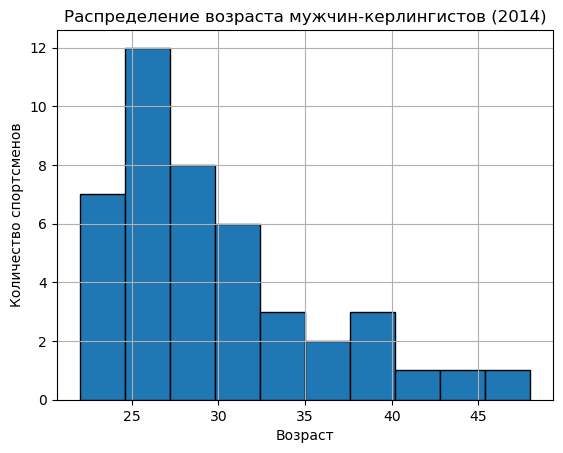

In [ ]:
curling_2014 = data[(data['Year'] == 2014) & (data['Sport'] == 'Curling') & (data['Sex'] == 'M')]
curling_2014['Age'].hist(edgecolor='black')
plt.title('Распределение возраста мужчин-керлингистов (2014)')
plt.xlabel('Возраст')
plt.ylabel('Количество спортсменов')
plt.show()

9. Рассмотрим зимнюю олимпиаду 2006 года. Сгруппируйте данные по стране
(используйте признак «NOC») и посчитайте для каждой страны количество
завоеванных медалей и средний возраст спортсменов. Выведите только те
страны, которые завоевали хотя бы одну медаль

In [57]:
winter_2006 = data[(data['Year'] == 2006) & (data['Season'] == 'Winter')].dropna(subset="Medal")
winter_2006.groupby("NOC").agg(
    Количество_медалей=('Medal', 'count'),
    Средний_возраст=('Age', 'mean')
).round(2)

,Количество_медалей,Средний_возраст
NOC,,
AUS,2,26.00
AUT,30,27.33
BLR,1,28.00
BUL,1,28.00
CAN,69,27.45
CHN,13,24.46
CRO,3,24.67
CZE,27,29.81
EST,3,30.33


10. Продолжим рассматривать зимнюю олимпиаду 2006 года. Посчитайте,
сколько медалей каждого достоинства завоевала каждая из стран-участниц
(страны, не завоевавшие ни одной медали, можно не выводить). Для этого
сгруппируйте данные по стране и по виду медали. Представьте данные в
виде сводной таблицы (pivot_table). В сводной таблице не должно быть
отсутствующих значений (NaN), замените их на 0.

In [59]:
medals_pivot = pd.pivot_table(
    winter_2006,
    index='NOC',
    columns='Medal',
    values='ID',
    aggfunc='count',
    fill_value=0
)
medals_pivot

Medal,Bronze,Gold,Silver
NOC,,,
AUS,1,1,0
AUT,7,16,7
BLR,0,0,1
BUL,0,0,1
CAN,11,30,28
CHN,6,2,5
CRO,0,1,2
CZE,24,1,2
EST,0,3,0


## Задание 2

Загрузите данные из файла «telecom_churn.csv» о клиентах оператора сотовой
связи. Данные содержат, в числе прочих, следующие признаки:
* State – обозначение территории (штата)
* Area code – код города
* International plan – подключена ли услуга международного роуминга
* Number vmail messages – количество голосовых сообщений
* Total day minutes – суммарная продолжительность дневных звонков (в минутах)
* Total day calls – количество дневных звонков
* Total eve minutes, Total eve calls – аналогичные показатели по * вечерним звонкам
* Total night minutes, Total night calls – аналогично по ночным звонкам
* Customer service calls – количество звонков в службу поддержки
* Churn – отток клиентов (False – клиент активен, True – клиент * потерян, то есть расторг договор)

Остальные столбцы можно сразу проигнорировать при загрузке данных

1. Выведите общую информацию о датафрейме с помощью методов info или describe.
Есть ли отсутствующие данные?

In [ ]:
columns_to_load = [
    'State', 'Area code', 'International plan', 'Number vmail messages',
    'Total day minutes', 'Total day calls', 'Total eve minutes', 'Total eve calls',
    'Total night minutes', 'Total night calls', 'Customer service calls', 'Churn'
]

df = pd.read_csv("data/telecom_churn.csv", usecols=columns_to_load)
df.head(5)

,State,Area code,International plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Customer service calls,Churn
0,KS,415,No,25,265.1,110,197.4,99,244.7,91,1,False
1,OH,415,No,26,161.6,123,195.5,103,254.4,103,1,False
2,NJ,415,No,0,243.4,114,121.2,110,162.6,104,0,False
3,OH,408,Yes,0,299.4,71,61.9,88,196.9,89,2,False
4,OK,415,Yes,0,166.7,113,148.3,122,186.9,121,3,False


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Area code               3333 non-null   int64  
 2   International plan      3333 non-null   object 
 3   Number vmail messages   3333 non-null   int64  
 4   Total day minutes       3333 non-null   float64
 5   Total day calls         3333 non-null   int64  
 6   Total eve minutes       3333 non-null   float64
 7   Total eve calls         3333 non-null   int64  
 8   Total night minutes     3333 non-null   float64
 9   Total night calls       3333 non-null   int64  
 10  Customer service calls  3333 non-null   int64  
 11  Churn                   3333 non-null   bool   
dtypes: bool(1), float64(3), int64(6), object(2)
memory usage: 289.8+ KB


In [69]:
sum(df.isnull().sum())

0

2. С помощью метода value_counts определите, сколько клиентов активны, а сколько
потеряно. Сколько процентов клиентов в имеющихся данных активны, а сколько
потеряны?


In [70]:
df['Churn'].value_counts()

False    2850
True      483
Name: Churn, dtype: int64

In [ ]:
df['Churn'].value_counts(normalize=True) * 100

False    85.508551
True     14.491449
Name: Churn, dtype: float64

3. Добавьте дополнительный столбец в датафрейм – средняя продолжительность
одного звонка (вычислить как суммарная продолжительность всех звонков,
деленная на суммарное количество всех звонков). Отсортируйте данные по этому
значению по убыванию и выведите 10 первых записей.

In [75]:
total_dur = df['Total day minutes'] + df['Total eve minutes'] + df['Total night minutes']
total_count = df['Total day calls'] + df['Total eve calls'] + df['Total night calls']
df['Avg_call_duration'] = total_dur / total_count
df.sort_values('Avg_call_duration', ascending=False).head(10)

,State,Area code,International plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Customer service calls,Churn,Avg_call_duration
985,NY,415,Yes,0,346.8,55,249.5,79,275.4,102,1,True,3.693644
2824,OR,415,No,0,324.7,48,236.4,82,187.6,78,0,True,3.599519
244,VA,408,No,0,198.5,99,267.8,60,354.9,75,0,True,3.509402
2321,AR,408,No,0,154.6,56,263.0,84,367.7,89,1,False,3.429258
2033,NJ,408,No,0,217.6,87,279.0,71,250.7,65,2,True,3.351121
1709,NV,408,No,0,197.7,68,250.5,53,181.2,67,3,False,3.347872
2536,CT,408,No,0,294.2,100,232.5,53,195.0,64,0,True,3.325806
1686,CT,408,No,40,231.9,56,211.8,91,268.5,74,2,False,3.222624
649,MO,408,No,0,261.7,97,210.6,48,256.7,83,3,True,3.197368
2289,MS,415,Yes,23,245.5,54,292.7,83,184.0,90,1,False,3.181498


4. Сгруппируйте данные по значению поля «Churn» и вычислите среднюю
продолжительность одного звонка в каждой категории. Есть ли существенная
разница в средней продолжительности одного звонка между активными и
потерянными клиентами?

In [ ]:
df.groupby('Churn')['Avg_call_duration'].mean()
#Разница 0.15 минут, разница не существенная

Churn
False    1.938102
True     2.091193
Name: Avg_call_duration, dtype: float64

5. Сгруппируйте данные по значению поля «Churn» и вычислите среднее количество
звонков в службу поддержки в каждой категории. Есть ли существенная разница
между активными и потерянными клиентами?


In [79]:
df.groupby('Churn')['Customer service calls'].mean()

Churn
False    1.449825
True     2.229814
Name: Customer service calls, dtype: float64

In [80]:
avg_service_calls_by_churn = df.groupby('Churn')['Customer service calls'].mean()
print(avg_service_calls_by_churn)
print(f"\nРазница: {abs(avg_service_calls_by_churn[False] - avg_service_calls_by_churn[True]):.2f} звонков")
print("Вывод: разница существенная - потерянные клиенты звонят в поддержку почти в 2 раза чаще")

Churn
False    1.449825
True     2.229814
Name: Customer service calls, dtype: float64

Разница: 0.78 звонков
Вывод: разница существенная - потерянные клиенты звонят в поддержку почти в 2 раза чаще


6. Исследуйте подробнее связь между параметрами «Churn» и «Customer service calls»,
построив таблицу сопряженности (факторную таблицу) по этим признакам.
Подсказка: используйте функцию crosstab. При каком количестве звонков в
службу поддержки процент оттока становится существенно выше, чем в целом по
датафрейму? (В качестве уточнения фразы «существенно выше» можете
использовать «более 40%».)

In [96]:
crosstab = pd.crosstab(df['Customer service calls'], df['Churn'], normalize='index') * 100
crosstab

Churn,False,True
Customer service calls,,
0,86.800574,13.199426
1,89.669771,10.330229
2,88.537549,11.462451
3,89.743590,10.256410
4,54.216867,45.783133
5,39.393939,60.606061
6,36.363636,63.636364
7,44.444444,55.555556
8,50.000000,50.000000


In [97]:
# Поиск порога, где отток > 40%
high_churn_threshold = crosstab[crosstab[True] > 40].index.min()
print(f"Процент оттока становится выше 40% при {high_churn_threshold} звонках в поддержку")

Процент оттока становится выше 40% при 4 звонках в поддержку


7. Аналогично предыдущему пункту исследуйте связь между параметрами «Churn» и
«International plan». Можно ли утверждать, что процент оттока среди клиентов,
использующих международный роуминг, существенно выше или ниже, чем среди
клиентов, не использующих его?

In [ ]:
international_churn = pd.crosstab(df['International plan'], df['Churn'], normalize='index') * 100
international_churn
# Отток среди клиентов с международным роумингом: 42.41%
# Отток среди клиентов без международного роуминга: 11.5%
# Вывод: процент оттока среди клиентов с международным роумингом существенно выше (на 30.91%)

Churn,False,True
International plan,,
No,88.504983,11.495017
Yes,57.585139,42.414861


8. Добавьте в датафрейм столбец «Прогнозируемый отток», заполнив его на основе
значений столбцов «Customer service calls» и «International plan» (конкретное
условие сформулируйте самостоятельно, на основе результатов выполнения
предыдущих шагов). Сравните значение в этом столбце со значением столбца
«Churn». Если мы будем пользоваться построенным прогнозом, то какой процент
ошибок первого и второго рода (ложноположительных и ложноотрицательных)
мы получим?

In [ ]:
df['Прогнозируемый отток'] = (df['Customer service calls'] >= 4) | (df['International plan'] == 'yes')
# Ошибки первого рода (ложноположительные)
false_positives = ((df['Прогнозируемый отток'] == True) & (df['Churn'] == False)).sum()
total_active = (df['Churn'] == False).sum()
type1_error_rate = false_positives / total_active * 100

# Ошибки второго рода (ложноотрицательные) 
false_negatives = ((df['Прогнозируемый отток'] == False) & (df['Churn'] == True)).sum()
total_churned = (df['Churn'] == True).sum()
type2_error_rate = false_negatives / total_churned * 100

In [103]:
print(f"Ошибка первого рода (ложноположительные): {type1_error_rate:.2f}%")
print(f"Ошибка второго рода (ложноотрицательные): {type2_error_rate:.2f}%")

Ошибка первого рода (ложноположительные): 4.53%
Ошибка второго рода (ложноотрицательные): 71.43%


Ошибка первого рода (α): Процент активных клиентов, которых мы ошибочно пометим как ушедших. Это приведет к ненужным затратам на удержание лояльных клиентов.

Ошибка второго рода (β): Процент ушедших клиентов, которых мы не заметим. Это самые опасные ошибки - мы упустим клиентов, которых еще можно было спасти.